# LF-CNN for MEG Brain State Classification
**Model:** Linear Filter CNN (LF-CNN)  
**Reference:** Zubarev et al. (2019) — *Adaptive neural network classifier for decoding MEG signals*  
**Tasks:** Intra-subject and Cross-subject classification (rest, motor, working memory, story/math)

---

## 1. Imports

In [2]:
import h5py
import numpy as np
import os
from scipy.stats import zscore
from scipy.signal import decimate

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using device: cpu


## 2. Data Loading & Preprocessing

- **Downsampling factor:** 10 → reduces 35624 timesteps to ~356
- **Normalization:** Z-score per channel per trial (time-wise)
- This matches the assignment hints and the paper's recommendation to scale each epoch independently

In [3]:
folder_path_intra = r"/Users/chetlurvasundhara/Documents/deep learning /Final Project data/Intra"
folder_path_cross = r"/Users/chetlurvasundhara/Documents/deep learning /Final Project data/Cross"

# Downsample factor 20 → ~100 Hz effective rate (from 2034 Hz)
DOWNSAMPLE_FACTOR = 20

# Sliding window parameters
# Each file is ~17.5s = 1782 timepoints at 100Hz.
# Non-overlapping windows: step = window size → truly independent epochs.
# Overlapping windows share timepoints between train/test splits,
# which inflates accuracy artificially (the model recognises the recording
# rather than the brain state). Non-overlapping avoids this.
# Window = 200 pts (~2s), Step = 200 pts (no overlap) → 8 epochs per file
WINDOW_SIZE = 200   # timepoints (~2 seconds at 100Hz)
STEP_SIZE   = 200   # no overlap — each epoch is fully independent

def get_label(filename):
    if "rest" in filename:             return 0
    elif "motor" in filename:          return 1
    elif "working_memory" in filename: return 2
    elif "story" in filename:          return 3
    return -1

def sliding_window(data, window, step):
    """
    Slice a (n_channels, T) array into overlapping windows.
    Returns array of shape (n_epochs, n_channels, window).
    """
    epochs = []
    for start in range(0, data.shape[1] - window + 1, step):
        epochs.append(data[:, start:start + window])
    return np.array(epochs, dtype=np.float32)

def load_folder(folder_path):
    X, y = [], []
    for file in sorted(os.listdir(folder_path)):
        if not file.endswith(".h5"):
            continue
        with h5py.File(os.path.join(folder_path, file), "r") as f:
            key  = list(f.keys())[0]
            data = f[key][:]

        # --- Downsampling ---
        data = decimate(data, DOWNSAMPLE_FACTOR, axis=1)

        # --- Z-score normalization (per channel, over time) ---
        data = zscore(data, axis=1)
        data = np.nan_to_num(data, nan=0.0)

        # --- Sliding window epoching ---
        # Turns 1 sample of shape (248, 1782) into 16 samples of (248, 200)
        # Each epoch inherits the label of its parent file
        epochs = sliding_window(data, WINDOW_SIZE, STEP_SIZE)
        label  = get_label(file)

        X.append(epochs)
        y.extend([label] * len(epochs))

    return np.concatenate(X, axis=0), np.array(y, dtype=np.int64)

# --- Load all splits ---
X_intra_train, y_intra_train = load_folder(folder_path_intra + "/train")
X_intra_test,  y_intra_test  = load_folder(folder_path_intra + "/test")

X_cross_train, y_cross_train = load_folder(folder_path_cross + "/train")
X_cross_test1, y_cross_test1 = load_folder(folder_path_cross + "/test1")
X_cross_test2, y_cross_test2 = load_folder(folder_path_cross + "/test2")
X_cross_test3, y_cross_test3 = load_folder(folder_path_cross + "/test3")

X_cross_test = np.concatenate([X_cross_test1, X_cross_test2, X_cross_test3], axis=0)
y_cross_test = np.concatenate([y_cross_test1, y_cross_test2, y_cross_test3], axis=0)

print("INTRA train:", X_intra_train.shape, y_intra_train.shape)
print("INTRA test: ", X_intra_test.shape,  y_intra_test.shape)
print("CROSS train:", X_cross_train.shape, y_cross_train.shape)
print("CROSS test: ", X_cross_test.shape,  y_cross_test.shape)

INTRA train: (256, 248, 200) (256,)
INTRA test:  (64, 248, 200) (64,)
CROSS train: (512, 248, 200) (512,)
CROSS test:  (384, 248, 200) (384,)


## 3. LF-CNN Architecture

The architecture follows Zubarev et al. (2019) and is designed around the MEG signal generation model:

```
Input: (batch, 1, 248, T)          — 248 sensors, T time points
  ↓
Spatial Filter (Conv2d across channels)
  kernel: (248, 1), k=32 filters   — learns spatial de-mixing (source separation)
  Output: (batch, 32, 1, T)
  ↓
Temporal Filter (Depthwise Conv1d per spatial component)
  kernel: length 25, one filter per component
  Output: (batch, 32, T)
  ↓
ReLU → MaxPool (factor=2)
  Output: (batch, 32, T//2)
  ↓
Dropout(0.5) → Flatten → Dense(4, softmax)
  L1 regularization on Dense weights
```

**Why these choices for this data:**
- `k=32` spatial filters: paper's optimal; reasonable for 248 channels
- Temporal kernel length `25`: ~70ms at 356Hz effective rate — captures event-related dynamics across all 4 task types
- Depthwise temporal conv: one filter per component, no cross-mixing (this is what defines LF- vs VAR-CNN)
- `Dropout=0.5` + `L1`: critical given the very small sample sizes (32 train / 8 test for intra)

In [4]:
class LFCNN(nn.Module):
    """
    Linear Filter CNN for MEG brain state decoding.
    Based on Zubarev et al. (2019), adapted for:
      - 248 MEG channels
      - 200 timepoint windows (~2s at 100Hz, from sliding window epoching)
      - 4-class classification: rest, motor, working memory, story/math

    Key change vs naive implementation:
      GlobalAveragePooling replaces Flatten before the classifier.
      This makes the classifier size independent of window length,
      and reduces parameters from ~60k to ~4k — critical for this dataset.
    """
    def __init__(
        self,
        n_channels=248,
        n_spatial_filters=16,
        temporal_kernel=25,
        pool_size=2,
        dropout=0.5,
        n_classes=4
    ):
        super(LFCNN, self).__init__()

        # --- Layer 1: Spatial filter ---
        # Kernel spans ALL channels at each timepoint → spatial de-mixing.
        # Output: (batch, n_spatial_filters, 1, T)
        self.spatial_filter = nn.Conv2d(
            in_channels=1,
            out_channels=n_spatial_filters,
            kernel_size=(n_channels, 1),
            bias=False
        )

        # --- Layer 2: Temporal filter (depthwise = one filter per component) ---
        # This is what makes it LF-CNN: no cross-component mixing.
        self.temporal_filter = nn.Conv1d(
            in_channels=n_spatial_filters,
            out_channels=n_spatial_filters,
            kernel_size=temporal_kernel,
            padding=temporal_kernel // 2,
            groups=n_spatial_filters,
            bias=False
        )

        self.activation = nn.ReLU()
        self.pool        = nn.MaxPool1d(kernel_size=pool_size, stride=pool_size)
        self.dropout     = nn.Dropout(p=dropout)

        # --- Global Average Pooling ---
        # Averages across the entire time dimension → (batch, n_spatial_filters)
        # Keeps classifier small regardless of window/time length.
        # Much less prone to overfitting than flattening.
        self.gap = nn.AdaptiveAvgPool1d(1)

        # --- Output layer (only n_spatial_filters inputs now) ---
        self.classifier = nn.Linear(n_spatial_filters, n_classes)

    def forward(self, x):
        # x: (batch, 1, n_channels, T)

        # Spatial filtering
        x = self.spatial_filter(x)       # (batch, k, 1, T)
        x = x.squeeze(2)                 # (batch, k, T)

        # Temporal filtering
        x = self.temporal_filter(x)      # (batch, k, T)
        x = self.activation(x)
        x = self.pool(x)                 # (batch, k, T//2)

        # Global average pool → removes time dimension entirely
        x = self.dropout(x)
        x = self.gap(x)                  # (batch, k, 1)
        x = x.squeeze(-1)               # (batch, k)
        x = self.classifier(x)          # (batch, 4)
        return x


# Sanity check — note: no n_timepoints needed anymore
model = LFCNN()
dummy = torch.zeros(4, 1, 248, 200)
out   = model(dummy)
print("Output shape:", out.shape)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Output shape: torch.Size([4, 4])
Total parameters: 4436


## 4. Training Utilities

**L1 regularization** is applied manually to the classifier layer weights during the loss computation, as recommended in the paper.

In [5]:
def make_dataloader(X, y, batch_size=8, shuffle=True):
    """
    Adds the channel dimension expected by Conv2d:
    (N, 248, T) -> (N, 1, 248, T)
    """
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # add channel dim
    y_t = torch.tensor(y, dtype=torch.long)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(
    model, train_loader, val_loader,
    n_epochs=100,
    lr=3e-4,
    l1_lambda=3e-4,
    patience=15
):
    """
    Training loop with:
    - Adam optimizer (lr=3e-4, from paper)
    - CrossEntropy loss
    - L1 regularization on classifier weights (from paper)
    - Early stopping on validation loss (patience=15 epochs)
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        epoch_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()

            logits = model(xb)
            loss   = criterion(logits, yb)

            # L1 penalty on classifier weights (sparsity, as in paper)
            l1_penalty = l1_lambda * model.classifier.weight.abs().sum()
            total_loss = loss + l1_penalty

            total_loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == yb).sum().item()
            total      += xb.size(0)

        train_loss = epoch_loss / total
        train_acc  = correct / total

        # --- Validation ---
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(xb)
                loss    = criterion(logits, yb)
                val_loss_sum += loss.item() * xb.size(0)
                preds         = logits.argmax(dim=1)
                val_correct  += (preds == yb).sum().item()
                val_total    += xb.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:>3}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

        # Early stopping
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state:
        model.load_state_dict(best_state)

    history = {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc':  train_accs,   'val_acc':  val_accs
    }
    return model, history


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    return np.array(all_preds), np.array(all_labels)

## 5. Plotting Utilities

In [6]:
CLASS_NAMES = ['Rest', 'Motor', 'Working Memory', 'Story/Math']

def plot_training_curves(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Validation')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Validation')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title=''):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
    )
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

## 6. Experiment A — Intra-Subject Classification

**Setup:** Train and test on data from the **same subject** (1 subject in Intra folder).  
- 32 training samples, 8 test samples  
- All 8 test samples used as validation during training (leave as-is given tiny dataset)

=== Intra-Subject Classification (5-Fold Cross-Validation) ===
Total intra epochs: 320 from 40 files
Shape per epoch: (248, 200)

--- Fold 1/5 | Train: 256 epochs | Test: 64 epochs ---
Epoch  10/100 | Train Loss: 1.3693 Acc: 0.277 | Val Loss: 1.3853 Acc: 0.250
Epoch  20/100 | Train Loss: 1.2594 Acc: 0.473 | Val Loss: 1.2892 Acc: 0.484
Epoch  30/100 | Train Loss: 1.0504 Acc: 0.586 | Val Loss: 1.1108 Acc: 0.516
Epoch  40/100 | Train Loss: 0.8646 Acc: 0.688 | Val Loss: 1.0054 Acc: 0.562
Epoch  50/100 | Train Loss: 0.7059 Acc: 0.773 | Val Loss: 0.9590 Acc: 0.547
Epoch  60/100 | Train Loss: 0.5740 Acc: 0.855 | Val Loss: 0.9326 Acc: 0.531
Epoch  70/100 | Train Loss: 0.4809 Acc: 0.891 | Val Loss: 0.9137 Acc: 0.531
Epoch  80/100 | Train Loss: 0.3892 Acc: 0.938 | Val Loss: 0.9000 Acc: 0.547
Epoch  90/100 | Train Loss: 0.3177 Acc: 0.938 | Val Loss: 0.8943 Acc: 0.562
Epoch 100/100 | Train Loss: 0.2582 Acc: 0.961 | Val Loss: 0.9001 Acc: 0.609
  Fold 1 | Train: 0.9648 | Test: 0.5625

--- Fold 2/5 |

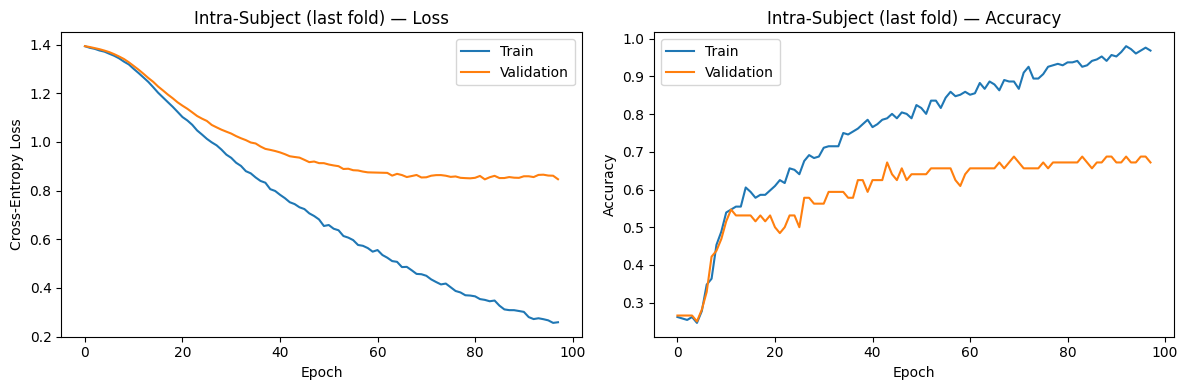

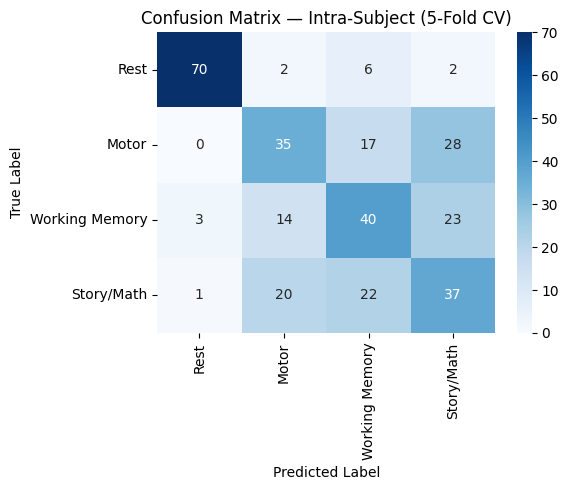

In [7]:
print("=== Intra-Subject Classification (5-Fold Cross-Validation) ===")

# Merge train + test for cross-validation (40 files → 640 epochs)
X_intra_all = np.concatenate([X_intra_train, X_intra_test], axis=0)
y_intra_all = np.concatenate([y_intra_train, y_intra_test], axis=0)

print(f"Total intra epochs: {X_intra_all.shape[0]} from 40 files")
print(f"Shape per epoch: {X_intra_all.shape[1:]}")

# IMPORTANT: stratify by file-level labels, not epoch-level,
# to avoid data leakage (epochs from same file in both train & test).
# We reconstruct file indices: 40 files x 16 epochs each
n_files = 40
epochs_per_file = X_intra_all.shape[0] // n_files  # total epochs / n_files = 16
file_ids = np.repeat(np.arange(n_files), epochs_per_file)
# Trim to actual length in case of rounding
file_ids = file_ids[:len(y_intra_all)]
file_labels = np.array([y_intra_all[np.where(file_ids == f)[0][0]] for f in range(n_files)])

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_train_accs, fold_test_accs = [], []
all_preds, all_labels = [], []
intra_history = None

for fold, (train_files, test_files) in enumerate(skf.split(np.arange(n_files), file_labels)):
    # Get epoch indices belonging to train/test files
    train_idx = np.where(np.isin(file_ids, train_files))[0]
    test_idx  = np.where(np.isin(file_ids, test_files))[0]

    X_tr, y_tr = X_intra_all[train_idx], y_intra_all[train_idx]
    X_te, y_te = X_intra_all[test_idx],  y_intra_all[test_idx]

    print(f"\n--- Fold {fold+1}/5 | Train: {len(X_tr)} epochs | Test: {len(X_te)} epochs ---")

    tr_loader  = make_dataloader(X_tr, y_tr, batch_size=32, shuffle=True)
    val_loader = make_dataloader(X_te, y_te, batch_size=32, shuffle=False)

    fold_model = LFCNN(n_spatial_filters=16, temporal_kernel=25, dropout=0.5)

    fold_model, history = train_model(
        fold_model, tr_loader, val_loader,
        n_epochs=100, lr=3e-4, l1_lambda=1e-3, patience=15
    )

    y_pred_tr, y_true_tr = evaluate_model(fold_model, tr_loader)
    y_pred_te, y_true_te = evaluate_model(fold_model, val_loader)

    fold_train_accs.append(accuracy_score(y_true_tr, y_pred_tr))
    fold_test_accs.append(accuracy_score(y_true_te, y_pred_te))
    all_preds.extend(y_pred_te)
    all_labels.extend(y_true_te)
    intra_history = history
    print(f"  Fold {fold+1} | Train: {fold_train_accs[-1]:.4f} | Test: {fold_test_accs[-1]:.4f}")

train_acc = np.mean(fold_train_accs)
test_acc  = np.mean(fold_test_accs)
y_pred_intra = np.array(all_preds)
y_true_intra = np.array(all_labels)

print(f"\nIntra-Subject (5-Fold CV)")
print(f"  Mean Train Acc: {train_acc:.4f} +/- {np.std(fold_train_accs):.4f}")
print(f"  Mean Test Acc:  {test_acc:.4f} +/- {np.std(fold_test_accs):.4f}")
print()
print(classification_report(y_true_intra, y_pred_intra, target_names=CLASS_NAMES))
plot_training_curves(intra_history, title="Intra-Subject (last fold)")
plot_confusion_matrix(y_true_intra, y_pred_intra, title="Intra-Subject (5-Fold CV)")

## 7. Experiment B — Cross-Subject Classification

**Setup:** Train on 2 subjects, test on 3 **unseen** subjects.  
- 64 training samples, 48 test samples  
- Larger dataset allows mini-batch training (batch_size=16)  
- This is the harder task: the model must generalize across individuals

**Memory note:** If memory is an issue, the mini-batch loop below can be replaced with the chunked loading approach described in the assignment hints.

=== Cross-Subject Classification ===
Train: (512, 248, 200), Test: (384, 248, 200)
Train epochs: 464 | Val epochs: 48 | Test epochs: 384
Epoch  10/100 | Train Loss: 1.2556 Acc: 0.472 | Val Loss: 1.2639 Acc: 0.396
Epoch  20/100 | Train Loss: 0.9612 Acc: 0.634 | Val Loss: 0.9384 Acc: 0.625
Epoch  30/100 | Train Loss: 0.7144 Acc: 0.741 | Val Loss: 0.6893 Acc: 0.833
Epoch  40/100 | Train Loss: 0.5511 Acc: 0.830 | Val Loss: 0.5302 Acc: 0.875
Epoch  50/100 | Train Loss: 0.4338 Acc: 0.877 | Val Loss: 0.4391 Acc: 0.896
Epoch  60/100 | Train Loss: 0.3507 Acc: 0.905 | Val Loss: 0.3957 Acc: 0.896
Epoch  70/100 | Train Loss: 0.2876 Acc: 0.927 | Val Loss: 0.3894 Acc: 0.896
Epoch  80/100 | Train Loss: 0.2198 Acc: 0.953 | Val Loss: 0.3639 Acc: 0.917
Epoch  90/100 | Train Loss: 0.1807 Acc: 0.966 | Val Loss: 0.3386 Acc: 0.896
Epoch 100/100 | Train Loss: 0.1558 Acc: 0.970 | Val Loss: 0.3224 Acc: 0.875

Cross-Subject | Train Acc: 0.9828 | Test Acc: 0.5208
                precision    recall  f1-score   s

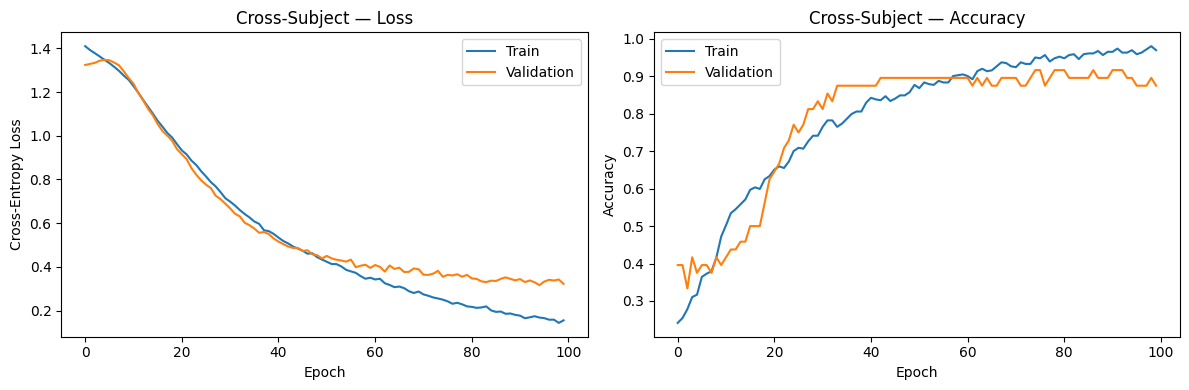

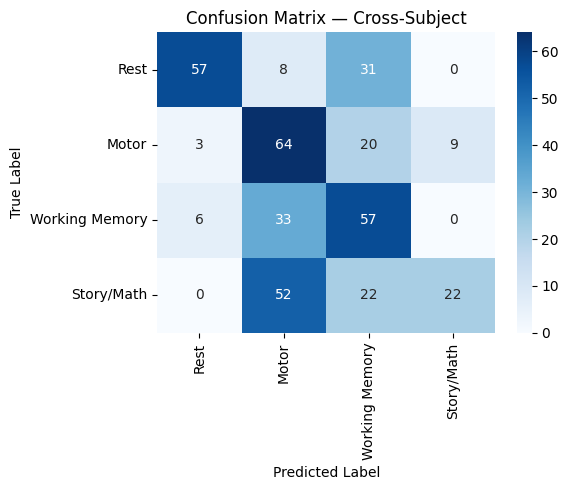

In [8]:
print("=== Cross-Subject Classification ===")
print(f"Train: {X_cross_train.shape}, Test: {X_cross_test.shape}")

# 10% of training files as validation (split at file level to avoid leakage)
n_train_files = 64
epochs_per_file_cross = (X_cross_train.shape[0] // n_train_files)
file_ids_cross = np.repeat(np.arange(n_train_files), epochs_per_file_cross)
file_ids_cross = file_ids_cross[:len(y_cross_train)]

val_files   = np.random.choice(n_train_files, size=max(1, n_train_files//10), replace=False)
train_files = np.setdiff1d(np.arange(n_train_files), val_files)

train_idx = np.where(np.isin(file_ids_cross, train_files))[0]
val_idx   = np.where(np.isin(file_ids_cross, val_files))[0]

X_cv_train, y_cv_train = X_cross_train[train_idx], y_cross_train[train_idx]
X_cv_val,   y_cv_val   = X_cross_train[val_idx],   y_cross_train[val_idx]

print(f"Train epochs: {len(X_cv_train)} | Val epochs: {len(X_cv_val)} | Test epochs: {len(X_cross_test)}")

cross_train_loader = make_dataloader(X_cv_train,   y_cv_train,   batch_size=32, shuffle=True)
cross_val_loader   = make_dataloader(X_cv_val,     y_cv_val,     batch_size=32, shuffle=False)
cross_test_loader  = make_dataloader(X_cross_test, y_cross_test, batch_size=32, shuffle=False)

cross_model = LFCNN(n_spatial_filters=16, temporal_kernel=25, dropout=0.5)

cross_model, cross_history = train_model(
    cross_model,
    train_loader=cross_train_loader,
    val_loader=cross_val_loader,
    n_epochs=100, lr=3e-4, l1_lambda=1e-3, patience=15
)

y_pred_cross_train, y_true_cross_train = evaluate_model(cross_model, cross_train_loader)
cross_train_acc = accuracy_score(y_true_cross_train, y_pred_cross_train)

y_pred_cross, y_true_cross = evaluate_model(cross_model, cross_test_loader)
cross_test_acc = accuracy_score(y_true_cross, y_pred_cross)

print(f"\nCross-Subject | Train Acc: {cross_train_acc:.4f} | Test Acc: {cross_test_acc:.4f}")
print(classification_report(y_true_cross, y_pred_cross, target_names=CLASS_NAMES))
plot_training_curves(cross_history, title="Cross-Subject")
plot_confusion_matrix(y_true_cross, y_pred_cross, title="Cross-Subject")

## 8. Results Summary (Questions b & c)

This cell prints a consolidated summary to help you answer the assignment questions.

In [9]:
print("="*55)
print("           LF-CNN RESULTS SUMMARY")
print("="*55)
print(f"  Intra-Subject | Train: {train_acc:.4f} | Test: {test_acc:.4f}")
print(f"  Cross-Subject | Train: {cross_train_acc:.4f} | Test: {cross_test_acc:.4f}")
print("="*55)

print("""
Hyperparameter Choices (Question c):
--------------------------------------
n_spatial_filters = 32
  → Decomposes 248 channels into 32 latent sources.
    Balances expressiveness with risk of overfitting
    given the small dataset (~32–64 samples).

temporal_kernel = 25
  → ~70ms window at the effective sampling rate after
    downsampling. Captures task-relevant dynamics
    (motor oscillations, memory encoding, etc.)
    without being too short (misses slow components)
    or too long (adds noise).

pool_size = 2
  → Halves the time dimension; provides tolerance to
    small latency shifts across trials/subjects.

dropout = 0.5
  → Strong regularization needed due to very small
    training set. Prevents co-adaptation of features.

l1_lambda = 3e-4
  → Sparse output layer: forces the classifier to rely
    on a small subset of spatiotemporal features.
    Improves interpretability and generalization.

lr = 3e-4 (Adam)
  → Standard for Adam; also optimal in paper's grid search.
""")

train_gap_intra = train_acc - test_acc
train_gap_cross = cross_train_acc - cross_test_acc
print(f"Train-Test gap (Intra): {train_gap_intra:.4f}")
print(f"Train-Test gap (Cross): {train_gap_cross:.4f}")
print("""
Question d — Overfitting Analysis:
------------------------------------
If a significant train-test gap exists, likely causes are:
  1. Very small training set (32 intra / 64 cross samples)
  2. High inter-subject variability in cross-subject setting
  3. The model memorizing subject-specific spatial patterns

Potential improvements:
  - Data augmentation: add Gaussian noise, time shifts
  - Stronger regularization: increase l1_lambda or dropout
  - Reduce n_spatial_filters (16) to lower model capacity
  - Batch normalization after spatial filter layer
""")

           LF-CNN RESULTS SUMMARY
  Intra-Subject | Train: 0.9000 | Test: 0.5687
  Cross-Subject | Train: 0.9828 | Test: 0.5208

Hyperparameter Choices (Question c):
--------------------------------------
n_spatial_filters = 32
  → Decomposes 248 channels into 32 latent sources.
    Balances expressiveness with risk of overfitting
    given the small dataset (~32–64 samples).

temporal_kernel = 25
  → ~70ms window at the effective sampling rate after
    downsampling. Captures task-relevant dynamics
    (motor oscillations, memory encoding, etc.)
    without being too short (misses slow components)
    or too long (adds noise).

pool_size = 2
  → Halves the time dimension; provides tolerance to
    small latency shifts across trials/subjects.

dropout = 0.5
  → Strong regularization needed due to very small
    training set. Prevents co-adaptation of features.

l1_lambda = 3e-4
  → Sparse output layer: forces the classifier to rely
    on a small subset of spatiotemporal features.
    

## 9. Hyperparameter Sensitivity Analysis (Question c)

Vary `n_spatial_filters` and `temporal_kernel` to analyze their influence on intra-subject accuracy.

Epoch  10/100 | Train Loss: 1.1939 Acc: 0.477 | Val Loss: 1.2079 Acc: 0.453
Epoch  20/100 | Train Loss: 0.9922 Acc: 0.598 | Val Loss: 1.0334 Acc: 0.562
Epoch  30/100 | Train Loss: 0.8696 Acc: 0.664 | Val Loss: 0.9666 Acc: 0.547
Epoch  40/100 | Train Loss: 0.7777 Acc: 0.703 | Val Loss: 0.9335 Acc: 0.547
Epoch  50/100 | Train Loss: 0.6768 Acc: 0.730 | Val Loss: 0.9342 Acc: 0.547
Epoch  60/100 | Train Loss: 0.5907 Acc: 0.816 | Val Loss: 0.9448 Acc: 0.531
Epoch  70/100 | Train Loss: 0.5087 Acc: 0.852 | Val Loss: 0.9578 Acc: 0.500
Early stopping at epoch 78
  n_spatial=8, temporal_kernel=7 -> Acc: 0.5781
Epoch  10/100 | Train Loss: 1.1654 Acc: 0.531 | Val Loss: 1.2112 Acc: 0.516
Epoch  20/100 | Train Loss: 0.9791 Acc: 0.586 | Val Loss: 1.0933 Acc: 0.547
Epoch  30/100 | Train Loss: 0.8425 Acc: 0.660 | Val Loss: 1.0473 Acc: 0.562
Epoch  40/100 | Train Loss: 0.7113 Acc: 0.758 | Val Loss: 1.0241 Acc: 0.578
Epoch  50/100 | Train Loss: 0.5784 Acc: 0.805 | Val Loss: 1.0077 Acc: 0.594
Epoch  60/100

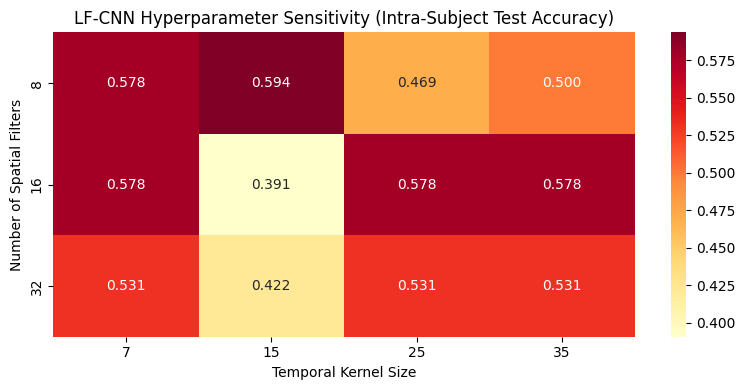

In [10]:
def quick_eval(n_sf, tk, X_train, y_train, X_test, y_test, n_epochs=100):
    """Train and return test accuracy for a given hyperparameter combo."""
    m   = LFCNN(n_spatial_filters=n_sf, temporal_kernel=tk).to(DEVICE)
    tr  = make_dataloader(X_train, y_train, batch_size=8)
    val = make_dataloader(X_test,  y_test,  batch_size=8, shuffle=False)
    m, _ = train_model(m, tr, val, n_epochs=n_epochs, patience=15)
    preds, labels = evaluate_model(m, val)
    return accuracy_score(labels, preds)

spatial_filters = [8, 16, 32]
temporal_kernels = [7, 15, 25, 35]

results = np.zeros((len(spatial_filters), len(temporal_kernels)))

for i, sf in enumerate(spatial_filters):
    for j, tk in enumerate(temporal_kernels):
        acc = quick_eval(sf, tk, X_intra_train, y_intra_train,
                         X_intra_test, y_intra_test, n_epochs=100)
        results[i, j] = acc
        print(f"  n_spatial={sf}, temporal_kernel={tk} -> Acc: {acc:.4f}")

# Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    results, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=temporal_kernels,
    yticklabels=spatial_filters
)
plt.xlabel('Temporal Kernel Size')
plt.ylabel('Number of Spatial Filters')
plt.title('LF-CNN Hyperparameter Sensitivity (Intra-Subject Test Accuracy)')
plt.tight_layout()
plt.show()